In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 2. Create Dataset (self-contained)
data = pd.DataFrame({
    'YearsExperience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7,
                        3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0,
                        6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5],
    'Salary': [39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189,
               63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940,
               91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872]
})

df=data

In [ ]:
df['experience_squerd'] = df['YearsExperience']**2


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df.isnull().sum()

,0
YearsExperience,0
Salary,0
experience_squerd,0


In [ ]:
df.columns

Index(['YearsExperience', 'Salary', 'experience_squerd'], dtype='object')

In [ ]:
X = df[['YearsExperience', 'experience_squerd']]
y = df['Salary']

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 27285.66834967611
Coefficients: [8497.96546216   80.62084747]


In [ ]:
y_pred = model.predict(x_test)
y_pred

array([116296.15408897,  70861.40566194, 102389.93092306,  74589.52490447,
        55304.71530665,  59831.83996149])

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("R2 Score in percentage:", int((r2)*100))

MAE : 6381.371429702191
MSE : 52527916.36877488
RMSE: 7247.614529538315
R2 Score: 0.8971645780890872
R2 Score in percentage: 89


In [ ]:
result = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred
})

result

,Actual Salary,Predicted Salary
0,112635,116296.154089
1,67938,70861.405662
2,113812,102389.930923
3,83088,74589.524904
4,64445,55304.715307
5,57189,59831.839961


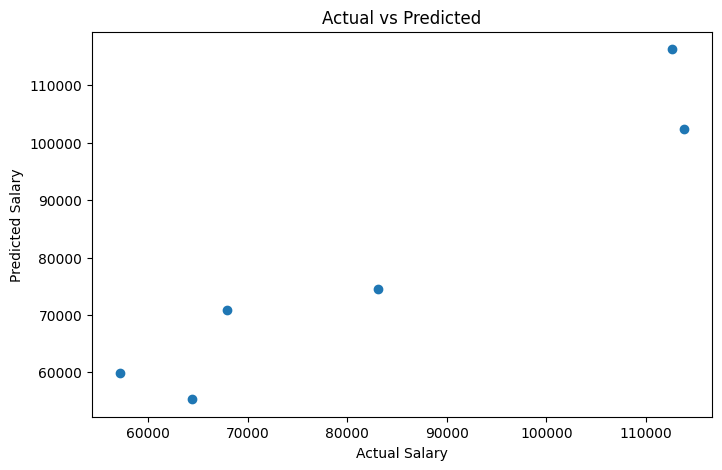

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

**Predict New Employee Salary :**

In [ ]:
new_data = pd.DataFrame({
    'YearsExperience':[2.4],
    'experience_squerd':[5.76]
})

# The model was trained on unscaled data, so we pass new_data directly.
prediction = model.predict(new_data)
print("Predicted Salary:", prediction[0])

Predicted Salary: 48145.16154026786


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   YearsExperience    30 non-null     float64
 1   Salary             30 non-null     int64  
 2   experience_squerd  30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


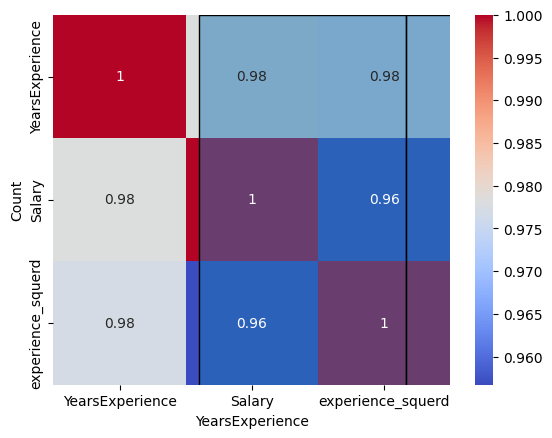

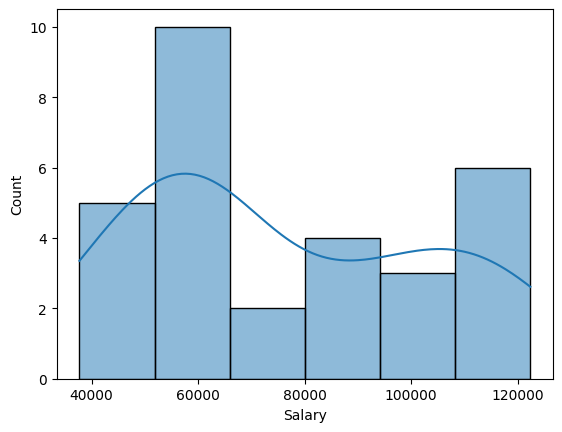

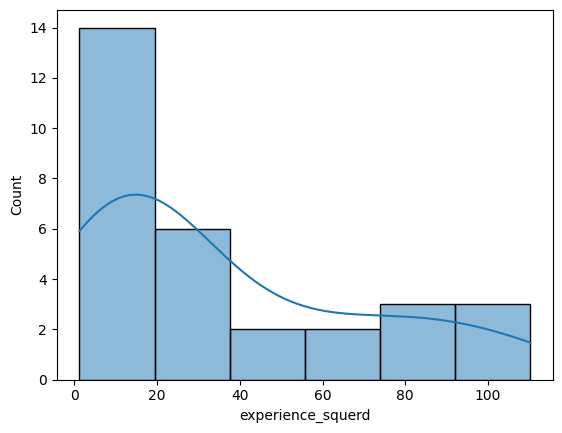

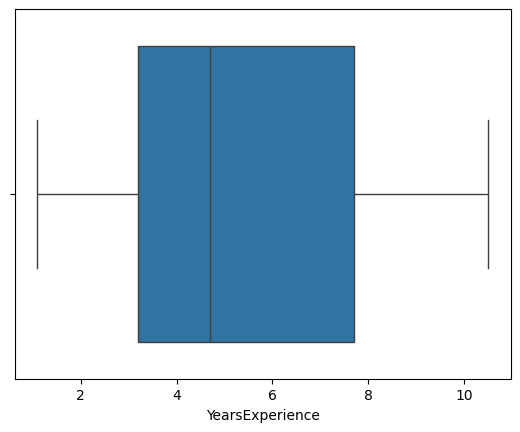

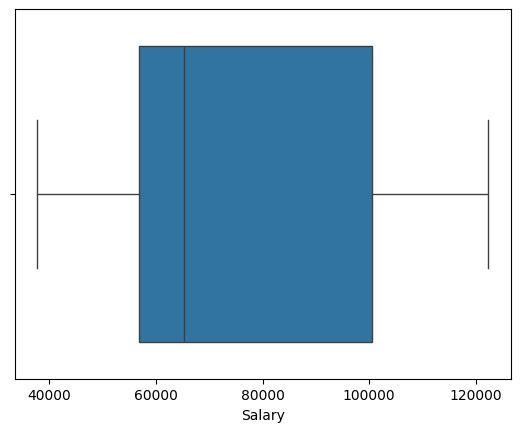

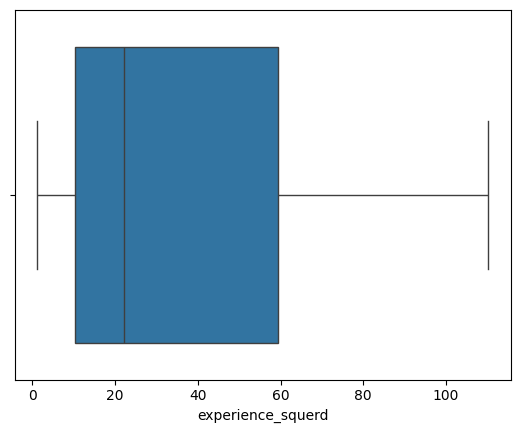

,Salary
YearsExperience,
1.1,39343.0
1.3,46205.0
1.5,37731.0
2.0,43525.0
2.2,39891.0
2.9,56642.0
3.0,60150.0
3.2,59445.0
3.7,57189.0


In [ ]:
# 1. Overview
df.head()
df.info()
df.describe()


# 2. Missing Values
df.isnull().sum()

# 3. Correlation
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

# 4. Distribution
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.select_dtypes(include='number').columns:
    sns.histplot(df[col], kde=True)
    plt.show()

# 5. Outliers
for col in df.select_dtypes(include='number').columns:
    sns.boxplot(x=df[col])
    plt.show()

# 6. Skewness
df.skew(numeric_only=True)  # >0 = right-skewed, <0 = left-skewed

# 7. Group-wise Analysis
df.groupby("YearsExperience")["Salary"].mean()